# 05. Market VWAP 타겟 데이터셋 생성

`04_target_policy.ipynb`에서 정리한 정책에 따라 모델링용 타겟 데이터셋을 생성한다.

## 예측 타겟 정의

| 컬럼 | 의미 |
|---|---|
| `market_vwap` | 같은 날짜에 실제 거래된 KAU 빈티지들의 VWAP를 거래량으로 합친 전체 거래 VWAP |
| `future_vwap_30d/60d` | 기준일에서 30일 또는 60일이 지난 뒤 처음 관측되는 `market_vwap` |
| `target_logret_30d/60d` | 기준일 `market_vwap` 대비 미래 `market_vwap`의 로그수익률 |
| `n_vintages`, `vintages`, `is_blended` | 해당 날짜 가격이 몇 개 빈티지를 합쳐 계산됐는지 확인하는 해석 보조 컬럼 |

`target_logret_30d = 0.05`이면 기준일 대비 약 30일 뒤 전체 거래 VWAP가 약 5.1% 상승한 것으로 해석한다. 실제로 며칠 뒤 가격을 썼는지는 `actual_elapsed_days_30d/60d`에 기록한다.

In [9]:
# 1. 환경 설정
from pathlib import Path
import json
import os
from urllib.parse import quote_plus

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
from dotenv import load_dotenv
from sqlalchemy import create_engine

if Path('/mnt/hgfs/Windows/Climate').exists():
    PROJECT_ROOT = Path('/mnt/hgfs/Windows/Climate')
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == 'notebooks':
        PROJECT_ROOT = PROJECT_ROOT.parent

SAVE_OUTPUT = False
OUTPUT_PARQUET = PROJECT_ROOT / 'data/processed/targets/target_market_vwap.parquet'
OUTPUT_SCHEMA = PROJECT_ROOT / 'data/processed/targets/schema_target_market_vwap.json'

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)
plt.rcParams['axes.unicode_minus'] = False

In [10]:
# 2. DB 연결 및 KRX ETS 원천 데이터 로드
load_dotenv(PROJECT_ROOT / '.env')
required_keys = ['DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD']
missing = [key for key in required_keys if not os.getenv(key)]
if missing:
    raise RuntimeError(f'필수 DB 환경변수가 없습니다: {missing}')

user = os.getenv('DB_USER')
password = quote_plus(os.getenv('DB_PASSWORD'))
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
db = os.getenv('DB_NAME')
engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{db}')

query = '''
select
    period,
    trd_dd,
    isu_code,
    clsprc,
    acc_trdvol,
    acc_trdval,
    vwap
from raw.krx_ets_daily
order by trd_dd, isu_code
'''

ets = pd.read_sql(query, engine, parse_dates=['trd_dd'])
ets['is_trade_day'] = (ets['acc_trdvol'] > 0) & (ets['vwap'] > 0)
ets_trade = ets[ets['is_trade_day']].copy().sort_values(['trd_dd', 'isu_code']).reset_index(drop=True)

source_summary = pd.DataFrame({
    '항목': [
        'raw.krx_ets_daily 전체 행 수',
        '실제 거래 행 수',
        '전체 거래일 수',
        '실제 거래가 있는 날짜 수',
        '시작일',
        '종료일',
        '실제 거래 빈티지 수',
    ],
    '값': [
        len(ets),
        len(ets_trade),
        ets['trd_dd'].nunique(),
        ets_trade['trd_dd'].nunique(),
        ets['trd_dd'].min().date(),
        ets['trd_dd'].max().date(),
        ets_trade['isu_code'].nunique(),
    ],
})
source_summary

,항목,값
0,raw.krx_ets_daily 전체 행 수,8213
1,실제 거래 행 수,2385
2,전체 거래일 수,2770
3,실제 거래가 있는 날짜 수,2132
4,시작일,2015-01-12
5,종료일,2026-04-23
6,실제 거래 빈티지 수,11


In [11]:
# 3. 전체 거래 VWAP 생성
# 같은 날짜에 여러 KAU 빈티지가 거래되면 해당 날짜의 실제 거래를 모두 합쳐 하나의 VWAP를 만든다.
# 이 방식은 날짜별 K-ETS 가격을 집계하는 규칙이다.

def join_codes(codes):
    return ','.join(sorted(codes))

market_base = ets_trade.assign(
    weighted_vwap_value=ets_trade['vwap'] * ets_trade['acc_trdvol']
)

market_daily = (
    market_base
    .groupby('trd_dd', as_index=False)
    .agg(
        market_vwap=('weighted_vwap_value', 'sum'),
        total_trdvol=('acc_trdvol', 'sum'),
        total_trdval=('acc_trdval', 'sum'),
        n_vintages=('isu_code', 'nunique'),
        vintages=('isu_code', join_codes),
    )
    .sort_values('trd_dd')
    .reset_index(drop=True)
)
market_daily['market_vwap'] = market_daily['market_vwap'] / market_daily['total_trdvol']
market_daily['vwap_from_trdval'] = market_daily['total_trdval'] / market_daily['total_trdvol']
market_daily['vwap_check_abs_diff'] = (market_daily['market_vwap'] - market_daily['vwap_from_trdval']).abs()
market_daily['is_blended'] = market_daily['n_vintages'] >= 2
market_daily['price_policy'] = 'market_vwap'

market_summary = pd.DataFrame({
    '항목': [
        'market_vwap 관측치 수',
        '시작일',
        '종료일',
        '2개 이상 빈티지를 합친 날짜 수',
        '2개 이상 빈티지를 합친 날짜 비율',
        '동일 날짜 최대 실제 거래 빈티지 수',
        '거래대금 기반 VWAP와의 최대 절대 차이',
    ],
    '값': [
        len(market_daily),
        market_daily['trd_dd'].min().date(),
        market_daily['trd_dd'].max().date(),
        int(market_daily['is_blended'].sum()),
        market_daily['is_blended'].mean(),
        int(market_daily['n_vintages'].max()),
        market_daily['vwap_check_abs_diff'].max(),
    ],
})
market_summary

,항목,값
0,market_vwap 관측치 수,2132
1,시작일,2015-01-12
2,종료일,2026-04-23
3,2개 이상 빈티지를 합친 날짜 수,252
4,2개 이상 빈티지를 합친 날짜 비율,0.118199
5,동일 날짜 최대 실제 거래 빈티지 수,3
6,거래대금 기반 VWAP와의 최대 절대 차이,0.5


In [12]:
# 4. 30일/60일 forward return 타겟 생성
# 기준일 + 예측 기간 이후 처음 관측되는 market_vwap를 미래 가격으로 사용한다.

def add_forward_return_targets(price_df, target_periods=(30, 60)):
    result = price_df.copy().sort_values('trd_dd').reset_index(drop=True)
    result['trd_dd'] = pd.to_datetime(result['trd_dd']).astype('datetime64[ns]')
    future_base = result[[
        'trd_dd',
        'market_vwap',
        'total_trdvol',
        'n_vintages',
        'is_blended',
    ]].copy()
    
    for target_period in target_periods:
        future = future_base.rename(columns={
            'trd_dd': f'future_date_{target_period}d',
            'market_vwap': f'future_vwap_{target_period}d',
            'total_trdvol': f'future_trdvol_{target_period}d',
            'n_vintages': f'future_n_vintages_{target_period}d',
            'is_blended': f'future_is_blended_{target_period}d',
        }).sort_values(f'future_date_{target_period}d')
        
        lookup = result[['trd_dd']].copy()
        lookup['_row_id'] = np.arange(len(lookup))
        lookup[f'target_lookup_date_{target_period}d'] = lookup['trd_dd'] + pd.Timedelta(days=target_period)
        lookup = lookup.sort_values(f'target_lookup_date_{target_period}d')
        
        matched = pd.merge_asof(
            lookup,
            future,
            left_on=f'target_lookup_date_{target_period}d',
            right_on=f'future_date_{target_period}d',
            direction='forward',
        ).sort_values('_row_id')
        
        for col in [
            f'target_lookup_date_{target_period}d',
            f'future_date_{target_period}d',
            f'future_vwap_{target_period}d',
            f'future_trdvol_{target_period}d',
            f'future_n_vintages_{target_period}d',
            f'future_is_blended_{target_period}d',
        ]:
            result[col] = matched[col].values
        
        result[f'actual_elapsed_days_{target_period}d'] = (
            result[f'future_date_{target_period}d'] - result['trd_dd']
        ).dt.days
        result[f'target_logret_{target_period}d'] = np.log(
            result[f'future_vwap_{target_period}d'] / result['market_vwap']
        )
        result[f'target_direction_{target_period}d'] = np.where(
            result[f'target_logret_{target_period}d'].isna(),
            pd.NA,
            (result[f'target_logret_{target_period}d'] > 0).astype('Int64'),
        )
    return result

target_df = add_forward_return_targets(market_daily, target_periods=(30, 60))

ordered_columns = [
    'trd_dd',
    'market_vwap',
    'total_trdvol',
    'total_trdval',
    'n_vintages',
    'vintages',
    'is_blended',
    'vwap_from_trdval',
    'vwap_check_abs_diff',
    'price_policy',
    'future_date_30d',
    'future_vwap_30d',
    'future_trdvol_30d',
    'future_n_vintages_30d',
    'future_is_blended_30d',
    'actual_elapsed_days_30d',
    'target_logret_30d',
    'target_direction_30d',
    'future_date_60d',
    'future_vwap_60d',
    'future_trdvol_60d',
    'future_n_vintages_60d',
    'future_is_blended_60d',
    'actual_elapsed_days_60d',
    'target_logret_60d',
    'target_direction_60d',
]
target_df = target_df[ordered_columns].copy()
target_df.head()

,trd_dd,market_vwap,total_trdvol,total_trdval,n_vintages,vintages,is_blended,vwap_from_trdval,vwap_check_abs_diff,price_policy,future_date_30d,future_vwap_30d,future_trdvol_30d,future_n_vintages_30d,future_is_blended_30d,actual_elapsed_days_30d,target_logret_30d,target_direction_30d,future_date_60d,future_vwap_60d,future_trdvol_60d,future_n_vintages_60d,future_is_blended_60d,actual_elapsed_days_60d,target_logret_60d,target_direction_60d
0,2015-01-12,8185.0,1190,9740400,1,KAU15,False,8185.210084,0.210084,market_vwap,2015-10-07,11300.0,12000.0,1.0,False,268.0,0.322500,1,2015-10-07,11300.0,12000.0,1.0,False,268.0,0.322500,1
1,2015-01-13,9500.0,50,475000,1,KAU15,False,9500.000000,0.000000,market_vwap,2015-10-07,11300.0,12000.0,1.0,False,267.0,0.173511,1,2015-10-07,11300.0,12000.0,1.0,False,267.0,0.173511,1
2,2015-01-14,9510.0,100,951000,1,KAU15,False,9510.000000,0.000000,market_vwap,2015-10-07,11300.0,12000.0,1.0,False,266.0,0.172459,1,2015-10-07,11300.0,12000.0,1.0,False,266.0,0.172459,1
3,2015-01-16,9610.0,40,384400,1,KAU15,False,9610.000000,0.000000,market_vwap,2015-10-07,11300.0,12000.0,1.0,False,264.0,0.161999,1,2015-10-07,11300.0,12000.0,1.0,False,264.0,0.161999,1
4,2015-10-07,11300.0,12000,135600000,1,KAU15,False,11300.000000,0.000000,market_vwap,2015-12-09,12100.0,100000.0,1.0,False,63.0,0.068403,1,2015-12-09,12100.0,100000.0,1.0,False,63.0,0.068403,1


In [13]:
# 5. 타겟 생성률과 실제 경과일 검증
summary_rows = []
for target_period in [30, 60]:
    target_col = f'target_logret_{target_period}d'
    elapsed_col = f'actual_elapsed_days_{target_period}d'
    valid = target_df[target_col].notna()
    elapsed_days = target_df.loc[valid, elapsed_col]
    summary_rows.append({
        'target': target_col,
        'base_obs': len(target_df),
        'target_obs': int(valid.sum()),
        'coverage': valid.mean(),
        'actual_elapsed_median_days': elapsed_days.median(),
        'actual_elapsed_p95_days': elapsed_days.quantile(0.95),
        'actual_elapsed_max_days': elapsed_days.max(),
        'base_blended_rate': target_df.loc[valid, 'is_blended'].mean(),
        'future_blended_rate': target_df.loc[valid, f'future_is_blended_{target_period}d'].mean(),
    })

target_summary = pd.DataFrame(summary_rows)
target_summary_display = target_summary.rename(columns={
    'target': '타겟',
    'base_obs': '기준 관측치 수',
    'target_obs': '타겟 생성 수',
    'coverage': '생성률',
    'actual_elapsed_median_days': '실제 경과일 중앙값',
    'actual_elapsed_p95_days': '실제 경과일 95% 분위',
    'actual_elapsed_max_days': '실제 경과일 최대값',
    'base_blended_rate': '기준일 blended 비율',
    'future_blended_rate': '미래일 blended 비율',
})
target_summary_display.style.format({
    '생성률': '{:.1%}',
    '실제 경과일 중앙값': '{:.0f}',
    '실제 경과일 95% 분위': '{:.0f}',
    '실제 경과일 최대값': '{:.0f}',
    '기준일 blended 비율': '{:.1%}',
    '미래일 blended 비율': '{:.1%}',
})

,타겟,기준 관측치 수,타겟 생성 수,생성률,실제 경과일 중앙값,실제 경과일 95% 분위,실제 경과일 최대값,기준일 blended 비율,미래일 blended 비율
0,target_logret_30d,2132,2110,99.0%,30,34,268,11.9%,11.4%
1,target_logret_60d,2132,2089,98.0%,60,64,268,12.1%,11.1%


In [14]:
# 6. target_logret 분포와 극단값 검증
return_rows = []
for target_period in [30, 60]:
    target_col = f'target_logret_{target_period}d'
    x = target_df[target_col].dropna()
    return_rows.append({
        'target': target_col,
        'mean': x.mean(),
        'std': x.std(),
        'min': x.min(),
        'p01': x.quantile(0.01),
        'median': x.median(),
        'p99': x.quantile(0.99),
        'max': x.max(),
        'positive_rate': (x > 0).mean(),
    })

return_summary = pd.DataFrame(return_rows)
return_summary_display = return_summary.rename(columns={
    'target': '타겟',
    'mean': '평균',
    'std': '표준편차',
    'min': '최소',
    'p01': '1% 분위',
    'median': '중앙값',
    'p99': '99% 분위',
    'max': '최대',
    'positive_rate': '상승 비율',
})

extreme_rows = []
for target_period in [30, 60]:
    target_col = f'target_logret_{target_period}d'
    top = target_df[target_df[target_col].notna()].copy()
    top['abs_target'] = top[target_col].abs()
    top = top.nlargest(5, 'abs_target')
    view = pd.DataFrame({
        'target': target_col,
        'trd_dd': top['trd_dd'],
        'market_vwap': top['market_vwap'],
        'target_value': top[target_col],
        'future_date': top[f'future_date_{target_period}d'],
        'future_vwap': top[f'future_vwap_{target_period}d'],
        'actual_elapsed_days': top[f'actual_elapsed_days_{target_period}d'],
        'n_vintages': top['n_vintages'],
        'vintages': top['vintages'],
        'is_blended': top['is_blended'],
        'future_n_vintages': top[f'future_n_vintages_{target_period}d'],
        'future_is_blended': top[f'future_is_blended_{target_period}d'],
    })
    extreme_rows.append(view)

extreme_returns = pd.concat(extreme_rows, ignore_index=True)

display(return_summary_display.style.format({
    '평균': '{:.4f}',
    '표준편차': '{:.4f}',
    '최소': '{:.4f}',
    '1% 분위': '{:.4f}',
    '중앙값': '{:.4f}',
    '99% 분위': '{:.4f}',
    '최대': '{:.4f}',
    '상승 비율': '{:.1%}',
}))

display(extreme_returns.style.format({
    'market_vwap': '{:,.2f}',
    'target_value': '{:.4f}',
    'future_vwap': '{:,.2f}',
    'actual_elapsed_days': '{:.0f}',
}))

,타겟,평균,표준편차,최소,1% 분위,중앙값,99% 분위,최대,상승 비율
0,target_logret_30d,-0.0030,0.1447,-0.6070,-0.3881,0.0048,0.4887,0.7201,52.7%
1,target_logret_60d,-0.0065,0.2034,-0.6458,-0.5048,0.0013,0.5525,0.9637,50.4%


,target,trd_dd,market_vwap,target_value,future_date,future_vwap,actual_elapsed_days,n_vintages,vintages,is_blended,future_n_vintages,future_is_blended
0,target_logret_30d,2021-06-22 00:00:00,"10,229.00",0.7201,2021-07-22 00:00:00,"21,017.00",30,1,KAU20,False,1.000000,False
1,target_logret_30d,2023-08-21 00:00:00,"7,386.20",0.6814,2023-09-20 00:00:00,"14,600.00",30,2,"KAU22,KAU23",True,1.000000,False
2,target_logret_30d,2023-08-29 00:00:00,"7,164.56",0.6699,2023-10-04 00:00:00,"14,000.00",36,2,"KAU22,KAU23",True,1.000000,False
3,target_logret_30d,2021-06-21 00:00:00,"10,785.33",0.6610,2021-07-21 00:00:00,"20,889.00",30,2,"KAU20,KAU21",True,1.000000,False
4,target_logret_30d,2023-08-30 00:00:00,"7,591.79",0.6120,2023-10-04 00:00:00,"14,000.00",35,2,"KAU22,KAU23",True,1.000000,False
5,target_logret_60d,2021-06-22 00:00:00,"10,229.00",0.9637,2021-08-23 00:00:00,"26,813.00",62,1,KAU20,False,1.000000,False
6,target_logret_60d,2021-06-21 00:00:00,"10,785.33",0.8959,2021-08-20 00:00:00,"26,420.00",60,2,"KAU20,KAU21",True,1.000000,False
7,target_logret_60d,2021-06-23 00:00:00,"11,502.00",0.8464,2021-08-23 00:00:00,"26,813.00",61,1,KAU20,False,1.000000,False
8,target_logret_60d,2022-06-14 00:00:00,"12,040.01",0.8109,2022-08-16 00:00:00,"27,088.00",63,2,"KAU21,KAU22",True,1.000000,False
9,target_logret_60d,2021-06-25 00:00:00,"13,298.00",0.7887,2021-08-24 00:00:00,"29,264.00",60,1,KAU20,False,1.000000,False


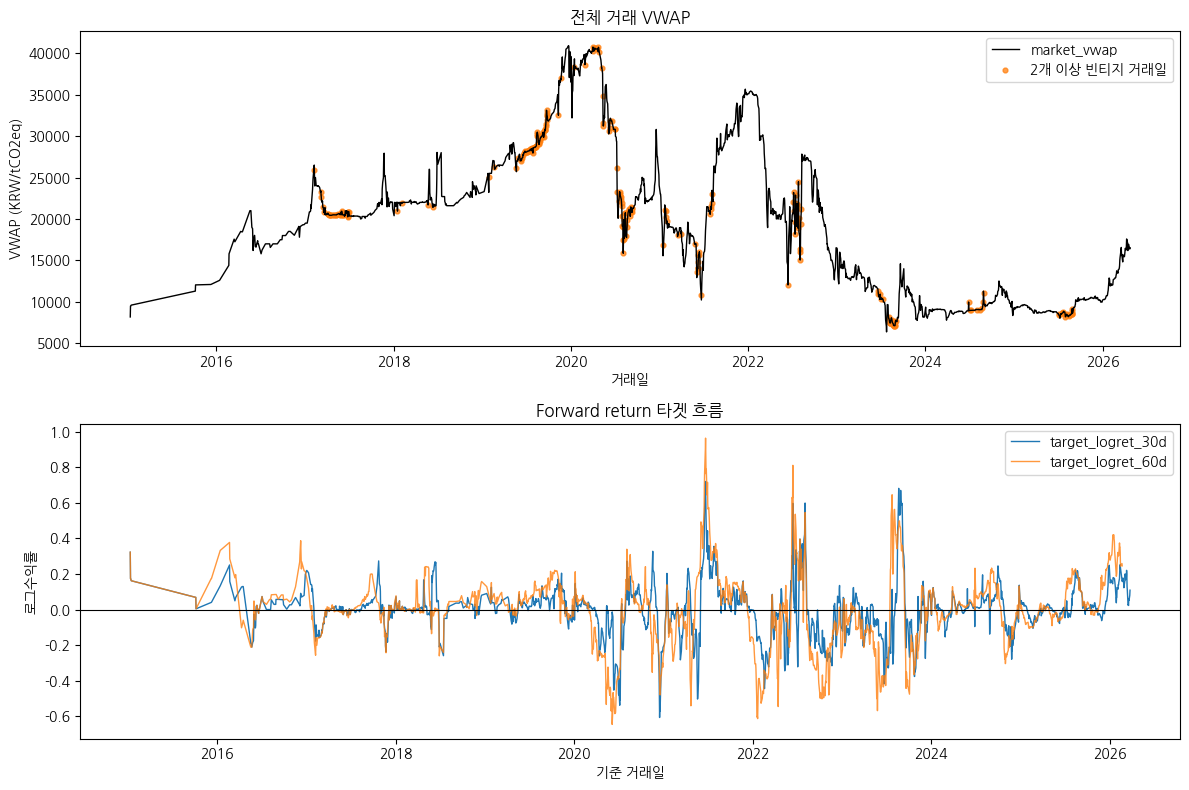

In [15]:
# 7. 전체 거래 VWAP와 타겟 흐름 확인
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

axes[0].plot(target_df['trd_dd'], target_df['market_vwap'], color='black', linewidth=1.0, label='market_vwap')
blended_points = target_df[target_df['is_blended']]
axes[0].scatter(blended_points['trd_dd'], blended_points['market_vwap'], s=12, color='tab:orange', alpha=0.75, label='2개 이상 빈티지 거래일')
axes[0].set_title('전체 거래 VWAP')
axes[0].set_xlabel('거래일')
axes[0].set_ylabel('VWAP (KRW/tCO2eq)')
axes[0].legend()

axes[1].plot(target_df['trd_dd'], target_df['target_logret_30d'], label='target_logret_30d', linewidth=1.0)
axes[1].plot(target_df['trd_dd'], target_df['target_logret_60d'], label='target_logret_60d', linewidth=1.0, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Forward return 타겟 흐름')
axes[1].set_xlabel('기준 거래일')
axes[1].set_ylabel('로그수익률')
axes[1].legend()

fig.tight_layout()
plt.show()

In [16]:
# 8. schema 확인
schema_rows = []
column_descriptions = {
    'trd_dd': '기준 거래일',
    'market_vwap': '기준일 전체 거래 VWAP',
    'total_trdvol': '기준일 전체 거래량',
    'total_trdval': '기준일 전체 거래대금',
    'n_vintages': '기준일 실제 거래 빈티지 수',
    'vintages': '기준일 실제 거래 빈티지 목록',
    'is_blended': '기준일 2개 이상 빈티지 거래 여부',
    'vwap_from_trdval': '거래대금/거래량 기반 확인용 VWAP',
    'vwap_check_abs_diff': 'market_vwap와 vwap_from_trdval 절대 차이',
    'price_policy': '가격 생성 정책',
    'future_date_30d': '30일 이후 처음 관측된 미래 거래일',
    'future_vwap_30d': '30일 미래 market_vwap',
    'future_trdvol_30d': '30일 미래 전체 거래량',
    'future_n_vintages_30d': '30일 미래 실제 거래 빈티지 수',
    'future_is_blended_30d': '30일 미래 2개 이상 빈티지 거래 여부',
    'actual_elapsed_days_30d': '기준일과 30일 미래 거래일 사이 실제 경과일',
    'target_logret_30d': '30일 forward log return',
    'target_direction_30d': '30일 forward return 상승 여부',
    'future_date_60d': '60일 이후 처음 관측된 미래 거래일',
    'future_vwap_60d': '60일 미래 market_vwap',
    'future_trdvol_60d': '60일 미래 전체 거래량',
    'future_n_vintages_60d': '60일 미래 실제 거래 빈티지 수',
    'future_is_blended_60d': '60일 미래 2개 이상 빈티지 거래 여부',
    'actual_elapsed_days_60d': '기준일과 60일 미래 거래일 사이 실제 경과일',
    'target_logret_60d': '60일 forward log return',
    'target_direction_60d': '60일 forward return 상승 여부',
}

for col in target_df.columns:
    schema_rows.append({
        'column': col,
        'dtype': str(target_df[col].dtype),
        'missing_count': int(target_df[col].isna().sum()),
        'missing_rate': target_df[col].isna().mean(),
        'description': column_descriptions[col],
    })

schema_df = pd.DataFrame(schema_rows)
schema_df.style.format({'missing_rate': '{:.1%}'})

,column,dtype,missing_count,missing_rate,description
0,trd_dd,datetime64[ns],0,0.0%,기준 거래일
1,market_vwap,float64,0,0.0%,기준일 전체 거래 VWAP
2,total_trdvol,int64,0,0.0%,기준일 전체 거래량
3,total_trdval,int64,0,0.0%,기준일 전체 거래대금
4,n_vintages,int64,0,0.0%,기준일 실제 거래 빈티지 수
5,vintages,str,0,0.0%,기준일 실제 거래 빈티지 목록
6,is_blended,bool,0,0.0%,기준일 2개 이상 빈티지 거래 여부
7,vwap_from_trdval,float64,0,0.0%,거래대금/거래량 기반 확인용 VWAP
8,vwap_check_abs_diff,float64,0,0.0%,market_vwap와 vwap_from_trdval 절대 차이
9,price_policy,str,0,0.0%,가격 생성 정책
